## Feature Engineering Approach
This notebook focuses on the feature engineering approach used for machinery fault classification and severity estimation. The notebook begins with loading and preprocessing raw triaxial vibration datasets collected from rotating machinery systems operating under different fault conditions. Signal processing techniques such as waveform segmentation and FFT analysis were applied to extract meaningful vibration characteristics from the X, Y, and Z axis signals.
A large number of statistical and frequency-domain features were engineered, including RMS, mean, standard deviation, peak-to-peak amplitude, dominant frequency, spectral energy, kurtosis, and combined-axis vibration metrics. These extracted features were then used to train and evaluate traditional machine learning models such as ExtraTrees Classifier, Random Forest, XGBoost, and LightGBM.
The notebook also includes model comparison, confusion matrix analysis, accuracy evaluation, macro F1-score analysis, and visualization of vibration behavior under different fault severity conditions. This notebook formed the foundation for the project’s interpretable and industry-oriented predictive maintenance pipeline.


## Import Libraries

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

## Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Bearing_fault_state_2000rpm_10mins.jsonl to Bearing_fault_state_2000rpm_10mins (1).jsonl
Saving Mechanical_looseness_state_2000rpm_10mins.jsonl to Mechanical_looseness_state_2000rpm_10mins (1).jsonl
Saving Misalignment_state_2000rpm_10mins.jsonl to Misalignment_state_2000rpm_10mins (1).jsonl
Saving Normal_state_2000rpm_3mins.jsonl to Normal_state_2000rpm_3mins (1).jsonl
Saving Normal_state_2000rpm_10mins.jsonl to Normal_state_2000rpm_10mins (1).jsonl
Saving Unbalance_state_2000rpm_10mins.jsonl to Unbalance_state_2000rpm_10mins (1).jsonl


## Load Data

In [6]:
data = []

for filename in uploaded.keys():
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            entry = json.loads(line)

            axis = entry.get('axis')
            values = entry.get('data')   # your files use 'data', not 'values'

            data.append({
                'axis': axis,
                'values': values,
                'label': filename.split('_state')[0].lower()
            })

df = pd.DataFrame(data)
df.head()

,axis,values,label
0,Y,"[10.740234375, -174.259765625, 253.740234375, ...",bearing_fault
1,Z,"[-145.162109375, -111.162109375, 89.837890625,...",bearing_fault
2,X,"[-251.4697265625, -128.4697265625, -617.469726...",bearing_fault
3,Y,"[-121.169921875, 17.830078125, 138.830078125, ...",bearing_fault
4,Z,"[11.3828125, 320.3828125, 700.3828125, 900.382...",bearing_fault


## Convert to Triaxial Samples

In [7]:
samples = []

for i in range(0, len(df), 3):
    try:
        x = df.iloc[i]['values']
        y = df.iloc[i+1]['values']
        z = df.iloc[i+2]['values']
        label = df.iloc[i]['label']

        samples.append({
            'x': x,
            'y': y,
            'z': z,
            'label': label
        })
    except:
        continue

samples_df = pd.DataFrame(samples)
samples_df.head()

,x,y,z,label
0,"[10.740234375, -174.259765625, 253.740234375, ...","[-145.162109375, -111.162109375, 89.837890625,...","[-251.4697265625, -128.4697265625, -617.469726...",bearing_fault
1,"[-121.169921875, 17.830078125, 138.830078125, ...","[11.3828125, 320.3828125, 700.3828125, 900.382...","[-531.8662109375, -991.8662109375, -673.866210...",bearing_fault
2,"[-71.0771484375, -124.0771484375, -80.07714843...","[-168.6513671875, -271.6513671875, -259.651367...","[404.359375, 73.359375, 35.359375, -267.640625...",bearing_fault
3,"[-216.9111328125, -720.9111328125, -213.911132...","[-114.275390625, -198.275390625, -146.27539062...","[261.255859375, 329.255859375, -176.744140625,...",bearing_fault
4,"[-564.14453125, -356.14453125, -210.14453125, ...","[1000.1376953125, 635.1376953125, 260.13769531...","[-123.5498046875, 563.4501953125, 234.45019531...",bearing_fault


## Feature Engineering

In [14]:
import numpy as np
import pandas as pd

SAMPLING_RATE = 50000  # 50 kHz
N_SAMPLES = 1024

def extract_time_features(signal):
    signal = np.array(signal, dtype=float)

    mean_val = np.mean(signal)
    std_val = np.std(signal)
    rms_val = np.sqrt(np.mean(signal**2))
    ptp_val = np.ptp(signal)
    kurt_val = pd.Series(signal).kurtosis()
    abs_mean_val = np.mean(np.abs(signal))

    return {
        "mean": mean_val,
        "std": std_val,
        "rms": rms_val,
        "peak_to_peak": ptp_val,
        "kurtosis": kurt_val,
        "abs_mean": abs_mean_val,
    }

def extract_fft_features(signal, sampling_rate=SAMPLING_RATE):
    signal = np.array(signal, dtype=float)

    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals)
    freqs = np.fft.rfftfreq(len(signal), d=1/sampling_rate)

    # Dominant frequency
    dom_idx = np.argmax(fft_mag[1:]) + 1 if len(fft_mag) > 1 else 0
    dom_freq = freqs[dom_idx]
    dom_amp = fft_mag[dom_idx]

    # Total spectral energy
    spectral_energy = np.sum(fft_mag**2)

    # High-frequency energy (> 5k Hz)
    high_freq_mask = freqs > 5000
    high_freq_energy = np.sum((fft_mag[high_freq_mask])**2)

    # Rotational frequency features for 2000 RPM
    rpm = 2000
    f1 = rpm / 60.0          # 1X
    f2 = 2 * f1              # 2X
    f3 = 3 * f1              # 3X

    def get_amp_near(target_freq, tol=5):
        mask = (freqs >= target_freq - tol) & (freqs <= target_freq + tol)
        if np.any(mask):
            return np.max(fft_mag[mask])
        return 0.0

    amp_1x = get_amp_near(f1)
    amp_2x = get_amp_near(f2)
    amp_3x = get_amp_near(f3)

    return {
        "dom_freq": dom_freq,
        "dom_amp": dom_amp,
        "spectral_energy": spectral_energy,
        "high_freq_energy": high_freq_energy,
        "fft_1x": amp_1x,
        "fft_2x": amp_2x,
        "fft_3x": amp_3x,
    }

features = []

for _, row in samples_df.iterrows():
    x = np.array(row["x"], dtype=float)
    y = np.array(row["y"], dtype=float)
    z = np.array(row["z"], dtype=float)

    fx_time = extract_time_features(x)
    fy_time = extract_time_features(y)
    fz_time = extract_time_features(z)

    fx_fft = extract_fft_features(x)
    fy_fft = extract_fft_features(y)
    fz_fft = extract_fft_features(z)

    feature_row = {}

    for k, v in fx_time.items():
        feature_row[f"x_{k}"] = v
    for k, v in fy_time.items():
        feature_row[f"y_{k}"] = v
    for k, v in fz_time.items():
        feature_row[f"z_{k}"] = v

    for k, v in fx_fft.items():
        feature_row[f"x_{k}"] = v
    for k, v in fy_fft.items():
        feature_row[f"y_{k}"] = v
    for k, v in fz_fft.items():
        feature_row[f"z_{k}"] = v

    # Cross-axis summary features
    feature_row["rms_mean_xyz"] = np.mean([feature_row["x_rms"], feature_row["y_rms"], feature_row["z_rms"]])
    feature_row["rms_max_xyz"] = np.max([feature_row["x_rms"], feature_row["y_rms"], feature_row["z_rms"]])
    feature_row["spectral_energy_mean_xyz"] = np.mean([
        feature_row["x_spectral_energy"],
        feature_row["y_spectral_energy"],
        feature_row["z_spectral_energy"]
    ])

    feature_row["label"] = row["label"]
    features.append(feature_row)

features_df = pd.DataFrame(features)
print(features_df.shape)
features_df.head()

(3772, 43)


,x_mean,x_std,x_rms,x_peak_to_peak,x_kurtosis,x_abs_mean,y_mean,y_std,y_rms,y_peak_to_peak,...,z_dom_amp,z_spectral_energy,z_high_freq_energy,z_fft_1x,z_fft_2x,z_fft_3x,rms_mean_xyz,rms_max_xyz,spectral_energy_mean_xyz,label
0,0.0,372.843980,372.843980,3228.0,2.426509,267.298271,0.0,592.659330,592.659330,6594.0,...,103410.776843,1.430772e+11,5.728628e+10,0.0,0.0,1523.500583,495.966551,592.659330,1.333713e+11,bearing_fault
1,0.0,268.130224,268.130224,2571.0,3.431430,196.948299,0.0,391.007101,391.007101,2983.0,...,73677.207089,3.422636e+10,1.372180e+10,0.0,0.0,13555.717863,304.879970,391.007101,5.069214e+10,bearing_fault
2,0.0,391.672736,391.672736,4166.0,2.959920,286.312717,0.0,206.473124,206.473124,1430.0,...,70737.874247,4.281637e+10,1.918405e+10,0.0,0.0,3950.971331,294.638010,391.672736,4.853255e+10,bearing_fault
3,0.0,197.999825,197.999825,1618.0,1.430342,151.517817,0.0,557.705254,557.705254,6595.0,...,51691.295688,3.360178e+10,1.413017e+10,0.0,0.0,2750.639893,336.287534,557.705254,7.240936e+10,bearing_fault
4,0.0,226.455398,226.455398,1766.0,0.663627,175.494186,0.0,420.969463,420.969463,4246.0,...,47881.167571,3.141141e+10,1.240624e+10,0.0,0.0,4702.843330,297.398267,420.969463,5.040374e+10,bearing_fault


## Prepare Data

In [15]:
from sklearn.model_selection import train_test_split

X = features_df.drop("label", axis=1)
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3017, 42)
Test shape: (755, 42)


## Train Model

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

## Evaluate Model

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8582781456953642
                      precision    recall  f1-score   support

       bearing_fault       0.99      0.99      0.99       146
mechanical_looseness       0.93      0.92      0.92       148
        misalignment       0.87      0.95      0.91       150
              normal       0.75      0.73      0.74       161
           unbalance       0.76      0.72      0.74       150

            accuracy                           0.86       755
           macro avg       0.86      0.86      0.86       755
        weighted avg       0.86      0.86      0.86       755



## Confusion Matrix (HEATMAP)

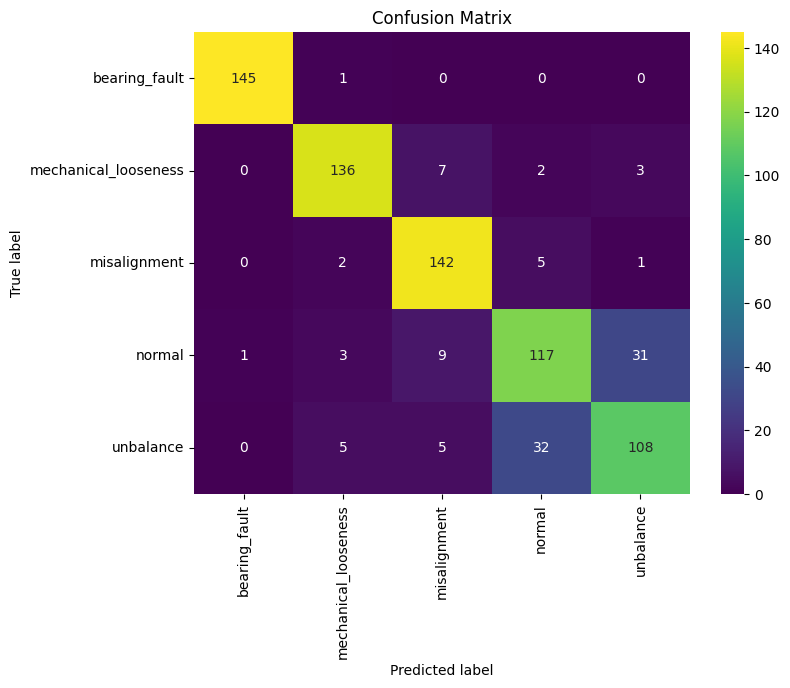

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

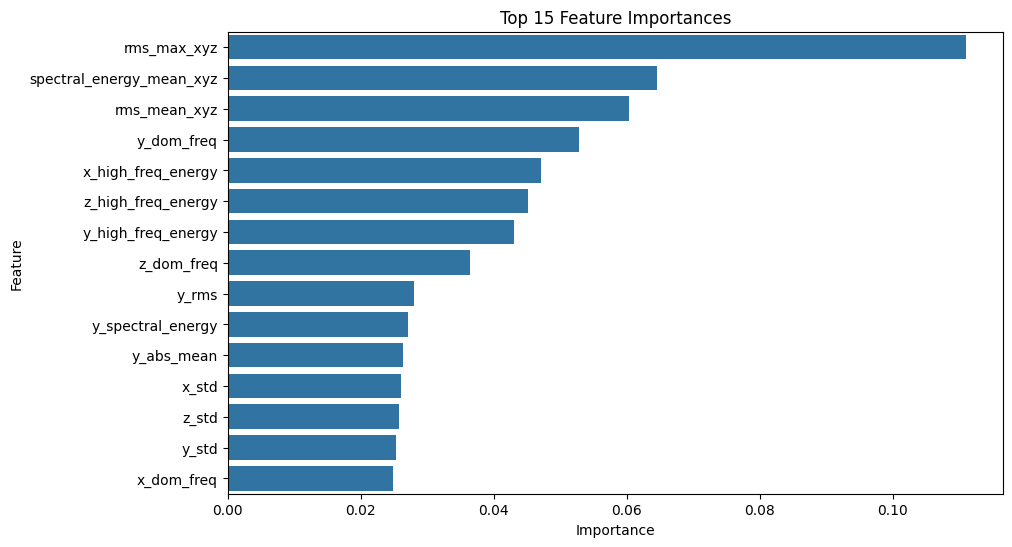

,feature,importance
40,rms_max_xyz,0.110980
41,spectral_energy_mean_xyz,0.064484
39,rms_mean_xyz,0.060340
25,y_dom_freq,0.052878
21,x_high_freq_energy,0.047102
35,z_high_freq_energy,0.045119
28,y_high_freq_energy,0.043000
32,z_dom_freq,0.036359
8,y_rms,0.027968
27,y_spectral_energy,0.027100


In [19]:
importances = model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top15 = fi_df.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top15, x="importance", y="feature")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

top15